2.1 Phân vùng theo histogram
2.1.1 Phương pháp Otsu

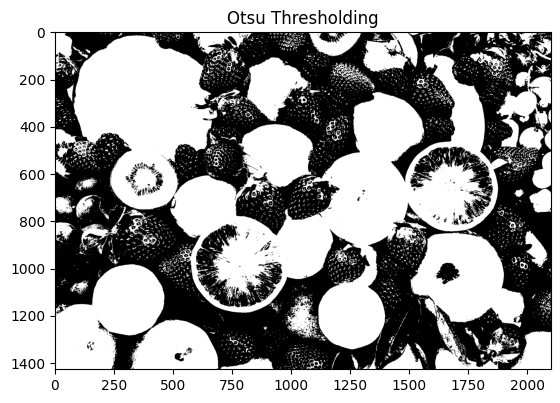

In [2]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

data = Image.open('images/fruit.jpg').convert('L')

a=np.asarray(data)
thres=threshold_otsu(a)
b=a>thres
b=Image.fromarray(b)
plt.imshow(b)
plt.title('Otsu Thresholding')
plt.show()

2.1.2 Phương pháp Adaptive Thresholding

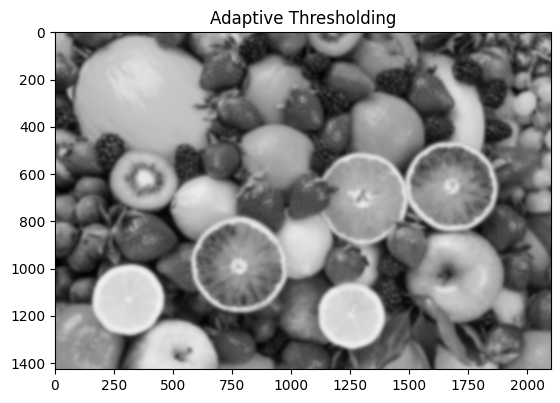

In [4]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = Image.open('images/fruit.jpg').convert('L')
a = np.asarray(data)
b = threshold_local(a, 39, offset=10)
b = Image.fromarray(b)

plt.imshow(b)
plt.title('Adaptive Thresholding')
plt.show()

2.2 Phân vùng theo region

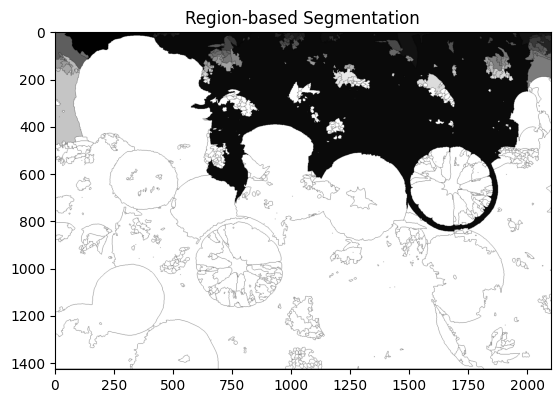

In [ ]:
import cv2
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

data = cv2.imread('images/fruit.jpg')
a=cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
b2 = cv2.erode(b1, None, iterations=2)
dist_trans=cv2.distanceTransform(b2, 2, 3)
thresh, dt = cv2.threshold(dist_trans,1,255,cv2.THRESH_BINARY)
labelled, mcc = label(dt)
cv2.watershed(data, labelled)
b = Image.fromarray(labelled)

plt.imshow(b)
plt.title('Phân vùng theo region')
plt.show()

2.3 Biến đổi đối tượng trong ảnh
2.3.1 Sử dụng binary_dilation

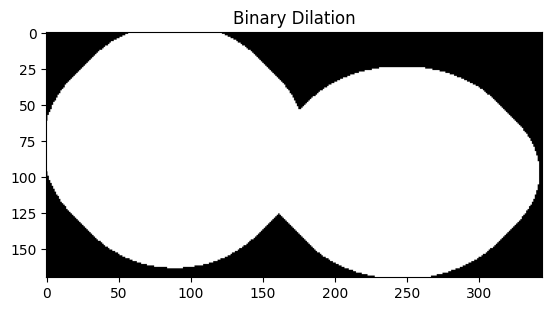

In [10]:
import cv2
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

data = Image.open('images/dil_img.png').convert('L')
a = np.array(data)
thresh = threshold_otsu(a)
binary = a > thresh  

b = nd.binary_dilation(binary, iterations=15)

c = Image.fromarray(b)  
c.show()
plt.imshow(c)
plt.title('Binary Dilation')
plt.show()

2.3.2 Sử dụng binary_opening

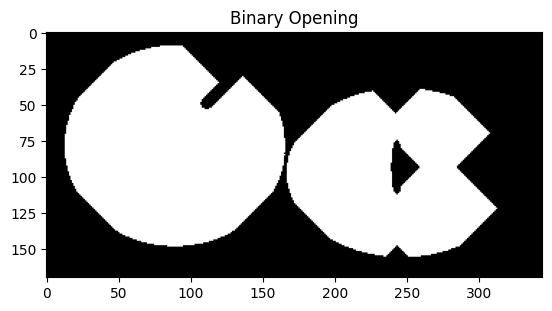

In [6]:
import cv2
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import imageio.v2 as iio
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

data = Image.open('images/dil_img.png').convert('L')
a = np.array(data)
thresh = threshold_otsu(a)
binary = a > thresh  
s=[[0,1,0],
   [1,1,1],
    [0,1,0]]
b = nd.binary_opening(binary, structure=s, iterations=25)
c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.title('Binary Opening')
plt.show()


2.3.3 Sử dụng binary_erosion

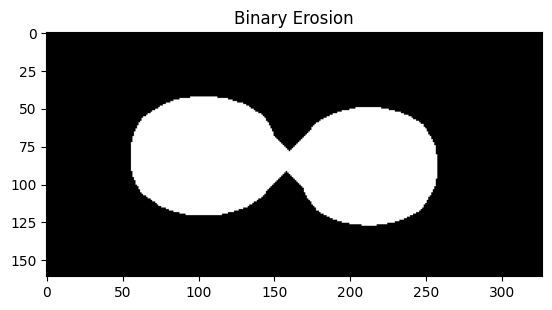

In [9]:
import cv2
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

data = Image.open('images/dil_img2.png').convert('L')
a = np.array(data)
thresh = threshold_otsu(a)
binary = a > thresh

s = [[0,1,0],
     [1,1,1],
     [0,1,0]]
b = nd.binary_erosion(binary, structure=s, iterations=10) 

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.title('Binary Erosion')
plt.show()

2.3.4 Sử dụng binary_closing

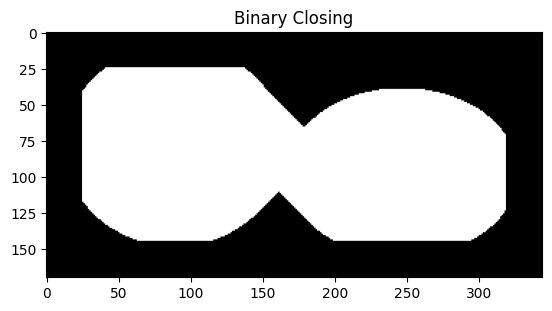

In [31]:
import cv2
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

data = Image.open('images/dil_img.png').convert('L')
a = np.array(data)
thresh = threshold_otsu(a)
binary = a > thresh

s = [[0,1,0],
     [1,1,1],
     [0,1,0]]

b = nd.binary_closing(binary, structure=s, iterations=25)
c = Image.fromarray(b)
c.show()
plt.imshow(c, cmap='gray')
plt.title('Binary Closing')

plt.show()